# Free Space Path Loss (FSPL)

Model the signal loss as the distance increases by modelling it using FSPL equations.

$$
FSPL = 20log(d) + 20log(f) - 147.55 - G_t - G_r
$$

Where:
- FSPL is in dB
- $d$ is the distance from the transmitter
- $f$ is the frequency of the wave, so 24MHz
- $G_t$ is the transmitter's gain
- $G_r$ is the receiver's gain. It's assumed this is 1 as the antenna is isotropic?

References:
- https://en.wikipedia.org/wiki/Free-space_path_loss
- https://www.pasternack.com/t-calculator-fspl.aspx
- https://www.bdamax.com/blog/db-vs-dbm-whats-the-real-difference/

In [51]:
import math

def signal_loss(distance :float, frequency = 2_400_000_000, transmitter_gain = 14, receiver_gain = 1):
    return 20 * math.log10(distance) + 20 * math.log10(frequency) - 147.55  - transmitter_gain - receiver_gain

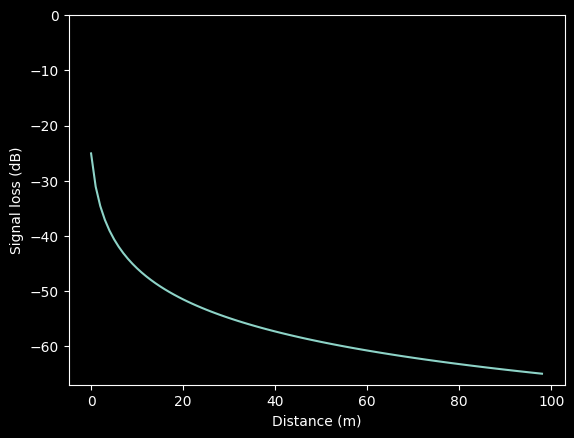

In [52]:
import matplotlib.pyplot as plt

points = []

for x in range (1, 100, 1):
    points.append(signal_loss(x) * - 1)

plt.plot(points)
plt.ylim(ymax=0)
plt.xlabel("Distance (m)")
plt.ylabel("Signal loss (dB)")
plt.show()

## Estimated vs Received Signal Strength

Model what the FSPL equation estimates the RSS should be at a given distance from the transmitter, and compare this to the actual signal strength received by the tag.

Looks at `/March 26 2025 Field Trial/straightpath5/` experiment, where the device moved ~106m.

Known inaccuracies:
- Real `transmitter_power` is unknown, but -6dBm fits the data
- The tag may not have travelled at a constant velocity in a straight line
- The entire dataset is used and it's assumed there are no pauses at the start/end and the tag doesn't retrace its steps

### Conclusion

The attenuation of the BLE signal mildly resemble the model of signal loss using FSPL equations.

### Transmitter E

First, look at transmitter A which is right by the start of the straight path

Standardising angles and times (shifting by 0.00 degrees)


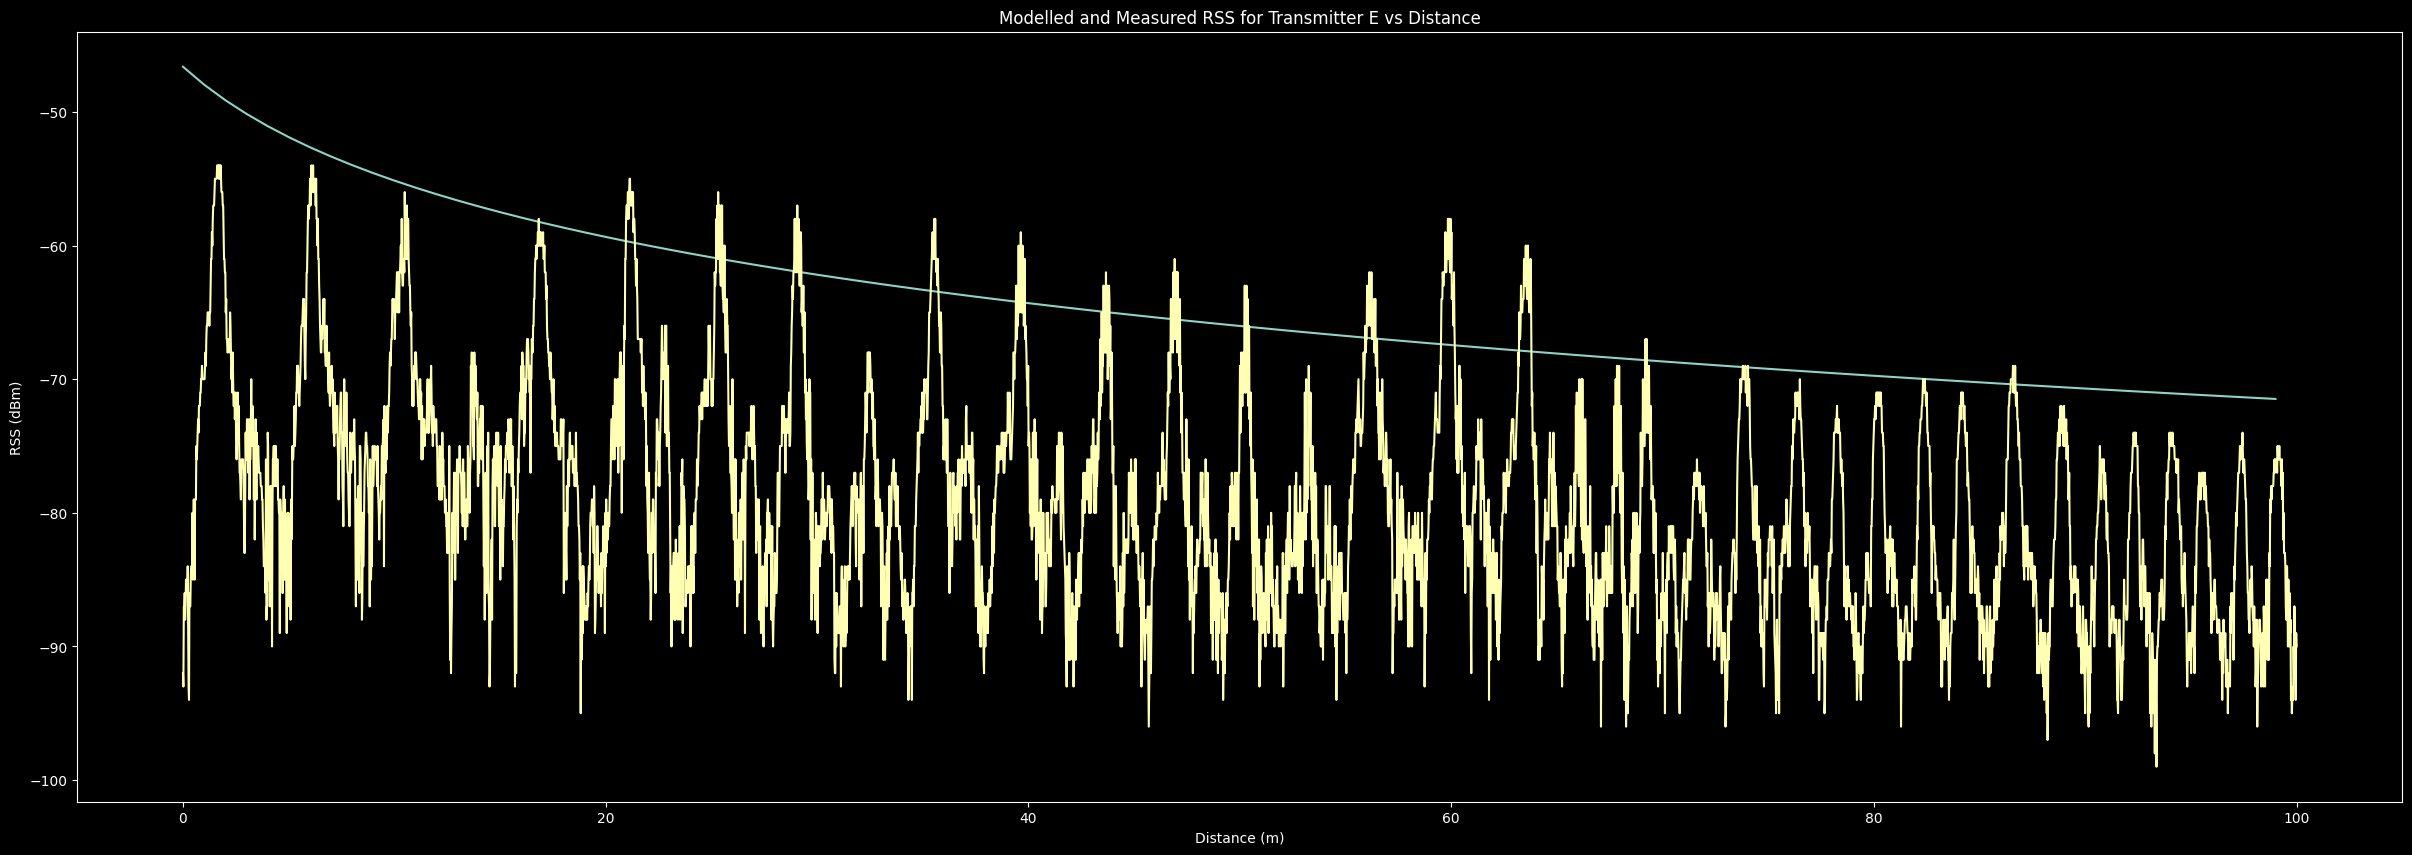

In [53]:
from BLEanalysis.signals import Signals
import numpy as np

transmitter_power = -6 # dBm
dist_travelled = 100 # m
num_data_points = 5000

# generate the model received signal strength
model_points = []

for x in range (6, dist_travelled + 6, 1):
    model_points.append(-1 * signal_loss(x) + transmitter_power)

# plot actual RSS from the tag
straight5_data = Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['e'],filetype='log',angleOffset=0).data[110:num_data_points,0]
tag_x = np.linspace(0, dist_travelled, num_data_points - 110)

# draw the graphs
plt.figure(figsize=(30,10))
plt.plot(model_points)
plt.plot(tag_x, straight5_data)
plt.ylabel("RSS (dBm)")
plt.xlabel("Distance (m)")
plt.title("Modelled and Measured RSS for Transmitter E vs Distance")
plt.show()

### Transmitter B

Examine the predicted and real RSS as the tag approaches transmitter B. It has been estimated the tag started 137m away and finished 37m away from the transmitter. Again, these measurements have been chosen on what fits the data.

Standardising angles and times (shifting by 0.00 degrees)


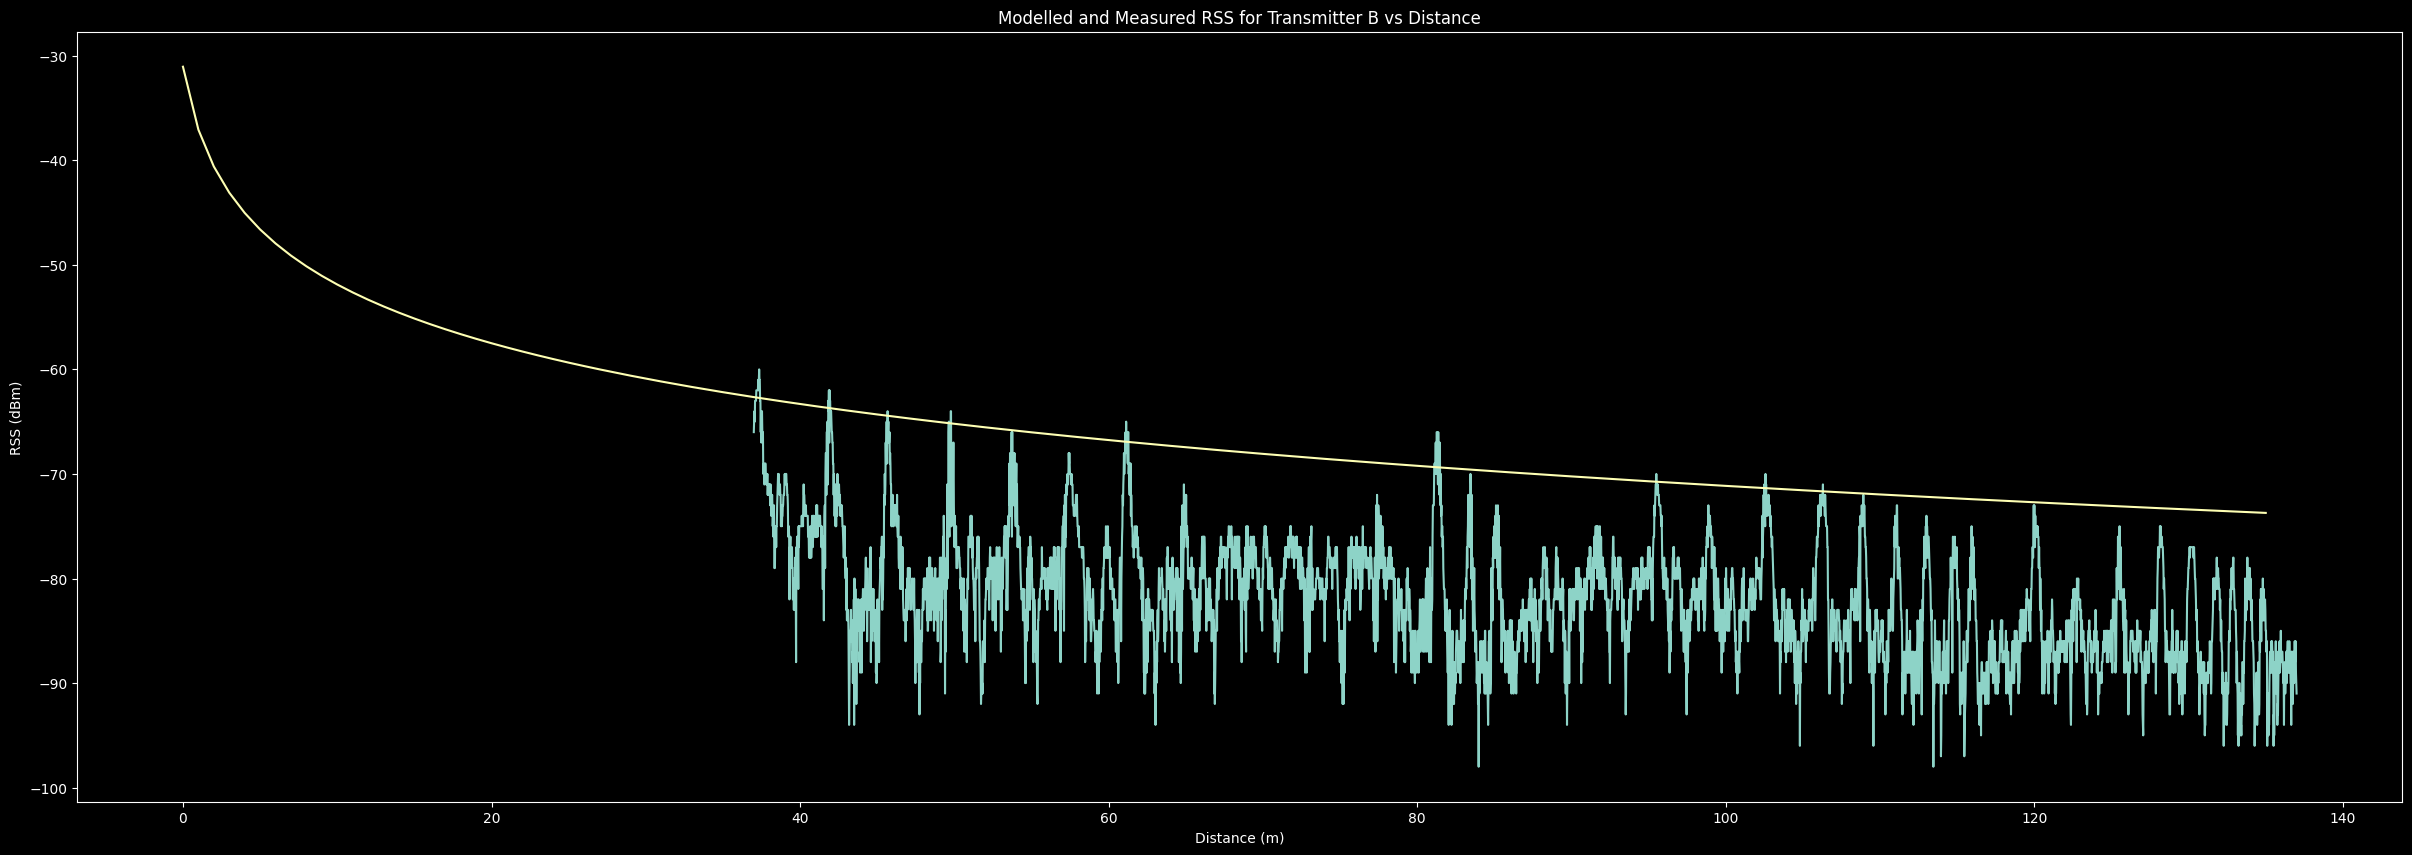

In [62]:
dist_remaining_to_b = 37 # m

straight5_data_b = np.flip(Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['b'],filetype='log',angleOffset=0).data[110:num_data_points,0])
tag_x = np.linspace(dist_remaining_to_b, dist_travelled + dist_remaining_to_b, num_data_points - 110)

b_model_points = []

for x in range (1, dist_travelled + dist_remaining_to_b, 1):
    b_model_points.append(-1 * signal_loss(x) + transmitter_power)

plt.figure(figsize=(30,10))
plt.plot(tag_x, straight5_data_b)
plt.plot(b_model_points)
plt.ylabel("RSS (dBm)")
plt.xlabel("Distance (m)")
plt.title("Modelled and Measured RSS for Transmitter B vs Distance")
plt.show()

### Subsample Bursts and Compare Peak RSS

Subsample bursts from the continuous recording of packets to replicate the behaviour of a real tag. Compare the peak RSS values received against the estimated value using FSPL. The maximum RSS per burst is used as FSPL assumes the transmitting and receiving antennas are pointing straight at each other.

Conclusion: Using any of the sampling methods gives results that are mildly related to the model line.

Standardising angles and times (shifting by 0.00 degrees)


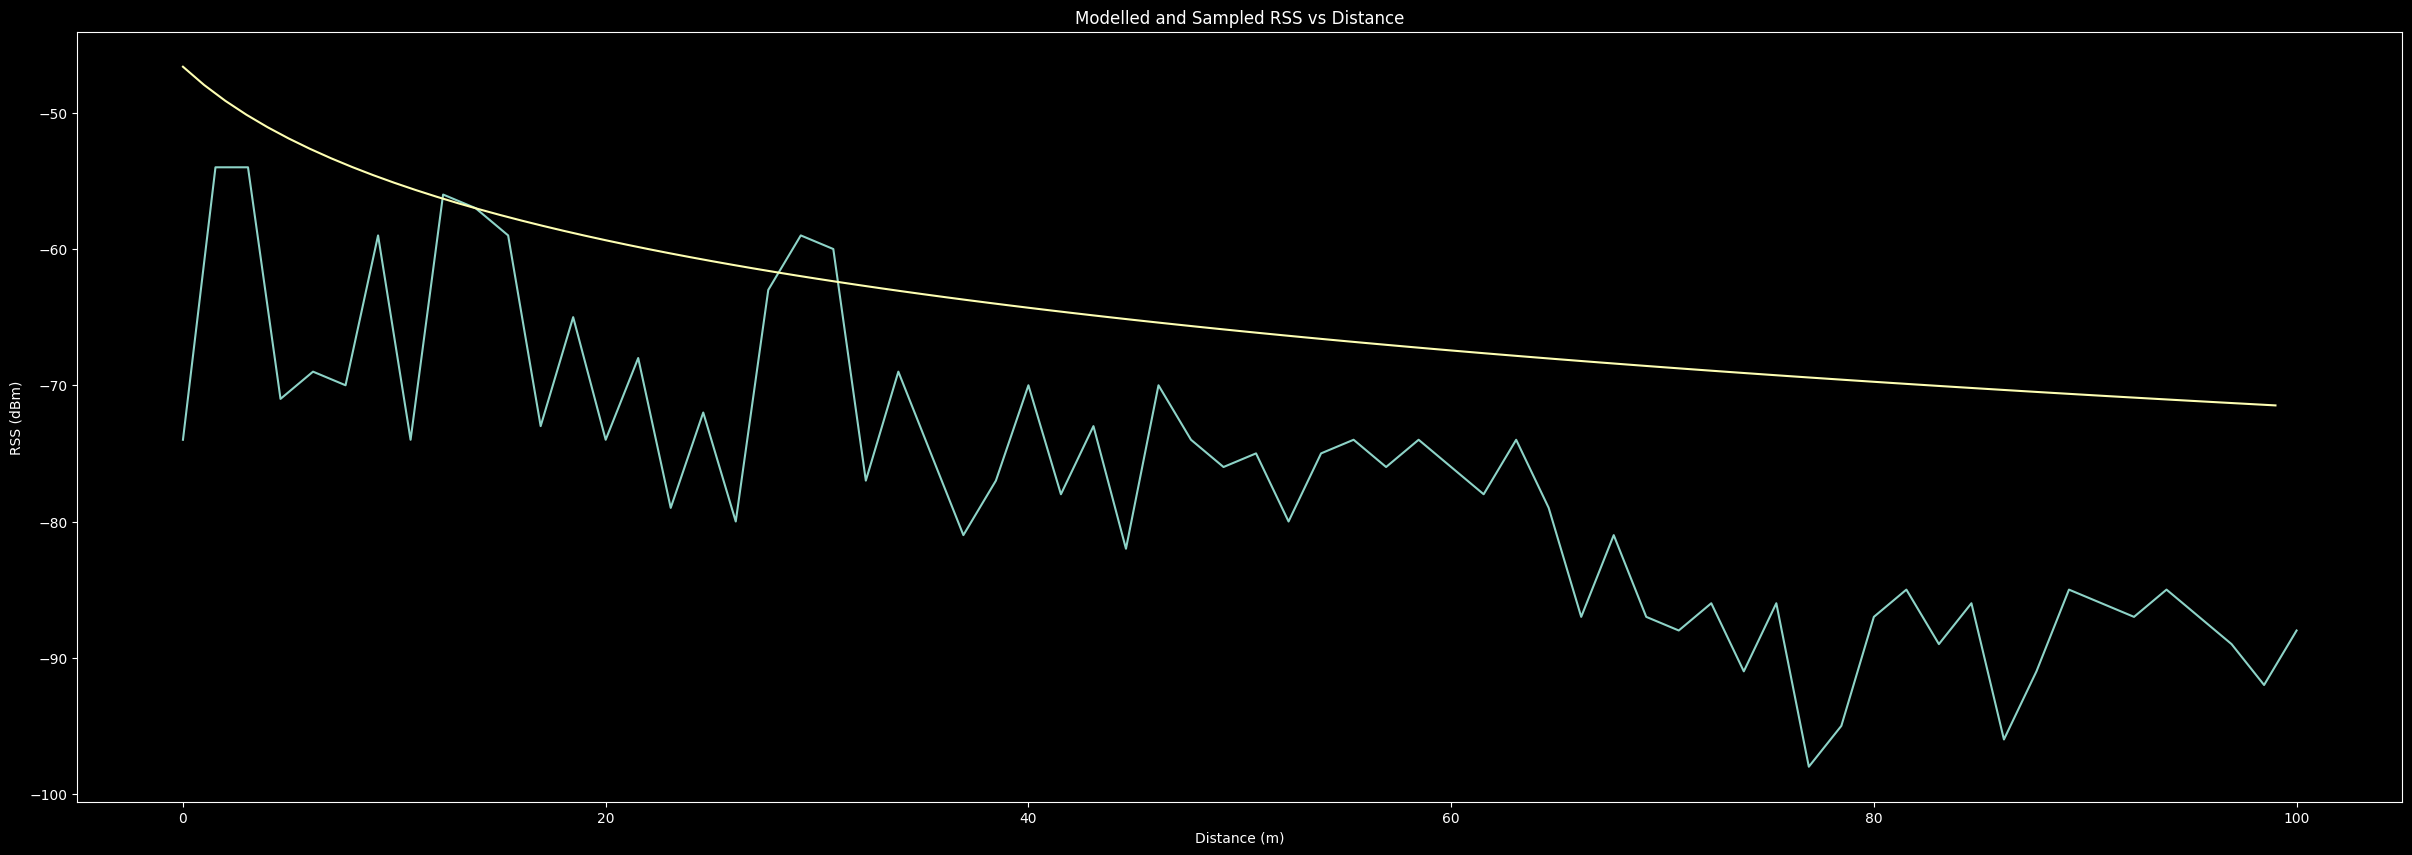

In [55]:
straight5 = Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['e'],filetype='log',angleOffset=0)
samples_per_burst = 7 # was 200

# get "bursts" from the large, continuous reading of packets
obs = []
obs_times = []
burst, time = straight5.parseBursts(burstInterval=0)
for b in range(len(burst)):
    new_burst = straight5.subsampleBurst(burst[b], samples_per_burst, 2000, method="random") # random, linspaceTimes, linspaceIdxs
    obs_times.append(time[b])
    obs.append(new_burst)

# plot the RSS of the sampled bursts onto a graph
burst_y = []
burst_x = np.linspace(0, dist_travelled, len(obs_times))

for x in range (len(obs_times)):
    burst_y.append(max(obs[x]['rssis']))

# plot the graph
plt.figure(figsize=(30,10))
plt.plot(burst_x, burst_y)
plt.plot(model_points) # plot estimated RSS from earlier
plt.ylabel("RSS (dBm)")
plt.xlabel("Distance (m)")
plt.title("Modelled and Sampled RSS vs Distance")
plt.show()